# ECON 5140: Applied Econometrics
## Lesson 12: Synthetic control (California Prop 99 + Python `pysyncon`)

This notebook combines two threads:

1. **Part 1 — California (CSV)** — Use `data/smoking_prop99.csv` (or the slim `data/california_prop99.csv`) to see **why a naive DID** (treated vs average donor) is fragile when **pre-trends differ**.
2. **Part 2 — Synthetic control in Python** — Fit **synthetic control** with **[pysyncon](https://github.com/sdfordham/pysyncon)**. The main specification uses the **Abadie et al. (2010)–style predictor set** (lagged cigarette sales plus covariate averages) from the **tidysynth** smoking panel saved as `data/smoking_prop99.csv`.
3. **Part 3** — **Placebo** inference over donor states (up to **`N_PLACEBO`**, capped by how many donors are in the data), using a **faster** SC spec than Part 2 (see Part 3 notes).
4. **Part 4** — **Pre-RMSPE** and comparison to an unweighted donor mean.
5. **Part 5** — **Augmented SC** (`pysyncon.AugSynth`, ridge ASC) and **SDID** (PyPI package `synthdid`).

### Reading: *Causal Inference: The Mixtape*

- **Chapter 10 — Synthetic Control:** [mixtape.scunning.com/10-synthetic_control](https://mixtape.scunning.com/10-synthetic_control)

### Prerequisites

- **Python:** `pip install pysyncon`. For Part 5 SDID: `pip install "synthdid==0.10.1" --no-deps` (in Jupyter use **`%pip`** so it targets the notebook kernel). Plain `pip install synthdid` pins old `numpy` and often fails on Python 3.12+. See `requirements.txt`. No R required.
- **Data:** `data/smoking_prop99.csv` (built from CRAN **tidysynth** `smoking.rda`; see `scripts/build_smoking_prop99_csv.py`).



## Setup

In [1]:
from __future__ import annotations

import warnings

import matplotlib

try:
    get_ipython()  # noqa: F821
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from pysyncon import AugSynth, Dataprep, Synth

warnings.filterwarnings("ignore")
np.random.seed(5140)

TREAT_YEAR = 1989

# Predictor windows (Abadie et al. / Synth replication style)
# — Covariate means over 1980–1988 (log income, age share, price); beer 1984–1988 (available in data).
# — Lagged outcome: PacksPerCapita in 1975, 1980, 1985, 1988 as separate moments (special_predictors).
# — SSR loss over last pre years 1984–1988.

TIME_PRED_COV_MEAN = list(range(1980, TREAT_YEAR))  # 1980–1988
BEER_YEARS = list(range(1984, TREAT_YEAR))


def load_panel() -> pd.DataFrame:
    """Full replication panel (tidysynth smoking); falls back to slim CSV if needed."""
    full = Path("data/smoking_prop99.csv")
    slim = Path("data/california_prop99.csv")
    if full.is_file():
        return pd.read_csv(full)
    if slim.is_file():
        return pd.read_csv(slim, sep=";")
    raise FileNotFoundError(
        "Missing data/smoking_prop99.csv (preferred) or data/california_prop99.csv. "
        "Run scripts/build_smoking_prop99_csv.py or add the synthdid california CSV."
    )


def california_sc_times(
    pre_predictors: list[int] | None = None,
    pre_ssr: list[int] | None = None,
) -> tuple[list[int], list[int]]:
    """Pre periods for predictor construction and for SSR loss."""
    df = load_panel()
    years = sorted(df["Year"].unique())
    pre_years = [y for y in years if y < TREAT_YEAR]
    if pre_predictors is None:
        pre_predictors = pre_years
    if pre_ssr is None:
        pre_ssr = [y for y in pre_years if y >= 1984]
    return pre_predictors, pre_ssr


def fit_synth_california(
    treated: str,
    controls: list[str],
    *,
    time_predictors_prior: list[int],
    time_optimize_ssr: list[int],
    paper_spec: bool = True,
) -> tuple[Synth, Dataprep]:
    """Synthetic control. `paper_spec=True` matches the textbook/paper predictor structure."""
    df = load_panel()
    if paper_spec and all(
        c in df.columns for c in ("lnincome", "beer", "age15to24", "retprice")
    ):
        special_predictors = [
            ("PacksPerCapita", [1988], "mean"),
            ("PacksPerCapita", [1985], "mean"),
            ("PacksPerCapita", [1980], "mean"),
            ("PacksPerCapita", [1975], "mean"),
            ("beer", BEER_YEARS, "mean"),
        ]
        dp = Dataprep(
            foo=df,
            predictors=["lnincome", "age15to24", "retprice"],
            predictors_op="mean",
            dependent="PacksPerCapita",
            unit_variable="State",
            time_variable="Year",
            treatment_identifier=treated,
            controls_identifier=controls,
            time_predictors_prior=TIME_PRED_COV_MEAN,
            time_optimize_ssr=time_optimize_ssr,
            special_predictors=special_predictors,
        )
    else:
        dp = Dataprep(
            foo=df,
            predictors=["PacksPerCapita"],
            predictors_op="mean",
            dependent="PacksPerCapita",
            unit_variable="State",
            time_variable="Year",
            treatment_identifier=treated,
            controls_identifier=controls,
            time_predictors_prior=time_predictors_prior,
            time_optimize_ssr=time_optimize_ssr,
        )
    synth = Synth()
    synth.fit(dataprep=dp)
    return synth, dp


def synth_outcome_paths(
    dp: Dataprep,
    synth: Synth,
    years: list[int],
) -> tuple[np.ndarray, np.ndarray, pd.Index]:
    """Treated path and synthetic control path for each year in `years`."""
    w = np.asarray(synth.W).ravel()
    z0, z1 = dp.make_outcome_mats(time_period=years)
    y_syn = z0.values @ w
    y1 = z1.values.ravel()
    return y1, y_syn, z1.index


def donor_mean_path(df: pd.DataFrame, donor_states: list[str], years: list[int]) -> np.ndarray:
    piv = df.pivot_table(index="Year", columns="State", values="PacksPerCapita")
    return piv.loc[years, donor_states].mean(axis=1).to_numpy(dtype=float)


def rmspe_pre_path(y_treated: np.ndarray, y_syn: np.ndarray, t0: int) -> float:
    e = y_treated[:t0] - y_syn[:t0]
    return float(np.sqrt(np.mean(e**2)))


def mean_post_gap(y_treated: np.ndarray, y_syn: np.ndarray, t0: int) -> float:
    return float(np.mean(y_treated[t0:] - y_syn[t0:]))


---
# Part 1: California data — why naive DID is fragile
---

**Setting:** **California** is the treated state (tobacco policy after **Proposition 99**; we take **1989** as the first post year). Donors are all **other states** in the file.

**Data:** `load_panel()` prefers **`data/smoking_prop99.csv`** (full covariates; same cigarette sales as the slim file).

**Parallel trends:** A standard **two-period DID** compares changes for treated vs a **single** control group. With **many pre years**, we can check whether California and a **simple average of donors** would have evolved similarly **without** treatment. If the **gap** (California minus donor mean) **drifts** in the pre period, treating the donor average as a valid counterfactual is questionable — so a raw DID can **confound** the policy effect with **pre-existing differences in trends**.

Below we **only plot and summarize** (no synthetic control yet).


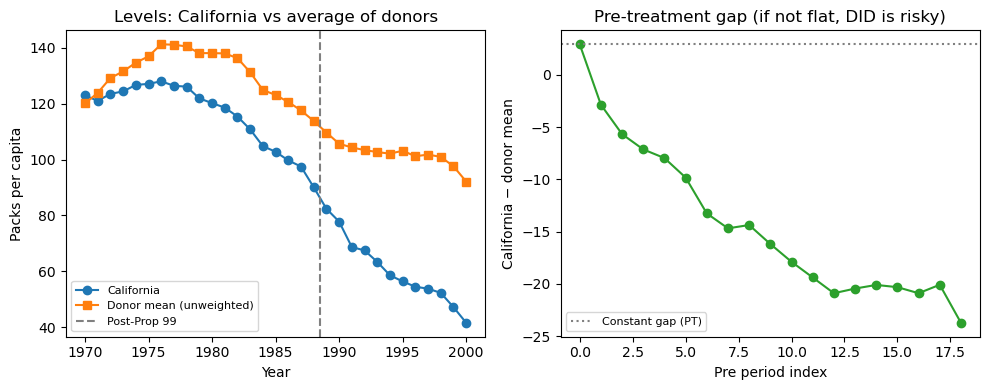

Illustrative 2×2-style comparison (first vs last year in panel):
  Δ California:  -81.40
  Δ Donor mean: -27.95
  Difference (DID-style): -53.45
If pre-trends differ, this difference mixes policy with trend bias; Part 2 fits synthetic control (pysyncon) so donors are weighted to match California pre paths.


In [2]:
df = load_panel()
years = sorted(df["Year"].unique().tolist())
T0 = years.index(TREAT_YEAR)  # pre: indices 0 .. T0-1

states = sorted(df["State"].unique())
donor_states = [s for s in states if s != "California"]


def _state_y(state: str) -> np.ndarray:
    s = df.loc[df["State"] == state].sort_values("Year")
    return s["PacksPerCapita"].to_numpy(dtype=float)


Y_ca = _state_y("California")
Y_donors = np.stack([_state_y(s) for s in donor_states], axis=0)
Y_agg = Y_donors.mean(axis=0)

t_year = np.asarray(years, dtype=float)
t_pre_idx = np.arange(T0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.plot(t_year, Y_ca, "o-", color="C0", label="California")
ax.plot(t_year, Y_agg, "s-", color="C1", label="Donor mean (unweighted)")
ax.axvline(TREAT_YEAR - 0.5, color="gray", linestyle="--", label="Post-Prop 99")
ax.set_xlabel("Year")
ax.set_ylabel("Packs per capita")
ax.set_title("Levels: California vs average of donors")
ax.legend(loc="best", fontsize=8)

gap_pre = Y_ca[:T0] - Y_agg[:T0]
ax = axes[1]
ax.plot(t_pre_idx, gap_pre, "o-", color="C2")
ax.axhline(gap_pre[0], color="gray", linestyle=":", label="Constant gap (PT)")
ax.set_xlabel("Pre period index")
ax.set_ylabel("California − donor mean")
ax.set_title("Pre-treatment gap (if not flat, DID is risky)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

pre_idx, post_idx = 0, -1
did_like = (Y_ca[post_idx] - Y_ca[pre_idx]) - (Y_agg[post_idx] - Y_agg[pre_idx])
print("Illustrative 2×2-style comparison (first vs last year in panel):")
print(f"  Δ California:  {Y_ca[post_idx] - Y_ca[pre_idx]:.2f}")
print(f"  Δ Donor mean: {Y_agg[post_idx] - Y_agg[pre_idx]:.2f}")
print(f"  Difference (DID-style): {did_like:.2f}")
print(
    "If pre-trends differ, this difference mixes policy with trend bias; "
    "Part 2 fits synthetic control (pysyncon) so donors are weighted to match California pre paths."
)


---
# Part 2: Synthetic control — California (pysyncon)
---

We estimate a **synthetic California** as a convex combination of **donor states** using **`pysyncon.Synth`** ([repo](https://github.com/sdfordham/pysyncon)). The API mirrors R’s **`Synth::dataprep` + `synth`**: build a **`Dataprep`**, then **`fit`**.

**Predictors (paper-style, when `smoking_prop99.csv` is present):**
- **Lagged outcome:** `PacksPerCapita` in **1975, 1980, 1985, 1988** (separate moments via `special_predictors`).
- **Covariate means (1980–1988):** `lnincome`, `age15to24`, `retprice`.
- **Beer sales:** mean over **1984–1988** (available in this dataset from 1984 onward).
- **SSR / loss window:** **1984–1988** (last five pre years before 1989).

If only the slim CSV is available, the code falls back to **mean `PacksPerCapita` only** over all pre years.

The next code cell plots **California vs synthetic** and the **pre-period SC residual**. The naive **California vs unweighted donor mean** comparison is already in **Part 1** (and RMSPE vs donor mean appears in **Part 4**).

**Note:** The full specification can take **~1–2 minutes** to fit (convex optimization over 38 donors).


California: pre-treatment fit — paper-style (lags + covariates)
  RMSPE synthetic: 2.3311   |   RMSPE vs donor mean: 16.0439
  Max |CA − synthetic| in pre (single year): 7.0614
  sum(w) over donors = 1.000000  (J = 38)


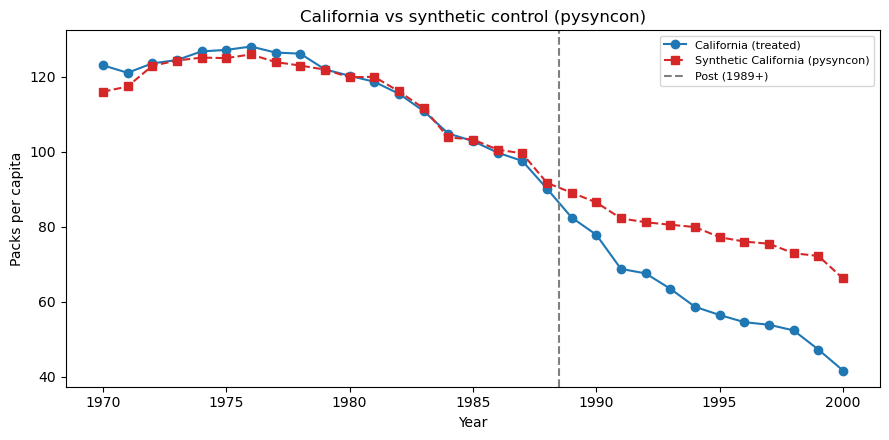

In [3]:
df = load_panel()
states = sorted(df["State"].unique())
donor_states = [s for s in states if s != "California"]
time_pred, time_opt = california_sc_times()

use_paper = all(c in df.columns for c in ("lnincome", "beer", "age15to24", "retprice"))
synth_ca, dp_ca = fit_synth_california(
    "California",
    donor_states,
    time_predictors_prior=time_pred,
    time_optimize_ssr=time_opt,
    paper_spec=use_paper,
)

years_all = sorted(df["Year"].unique())
Y_ca, Y_syn_ca, time_index = synth_outcome_paths(dp_ca, synth_ca, years_all)
T0 = int(np.searchsorted(time_index.to_numpy(), TREAT_YEAR))

w_ca = np.asarray(synth_ca.W).ravel()
piv = df.pivot_table(index="Year", columns="State", values="PacksPerCapita")
Y_donors = np.stack([piv.loc[years_all, s].to_numpy(dtype=float) for s in donor_states], axis=0)
donor_mean = Y_donors.mean(axis=0)

rmspe = rmspe_pre_path(Y_ca, Y_syn_ca, T0)
rmspe_naive = rmspe_pre_path(Y_ca, donor_mean, T0)
max_pre_gap = float(np.max(np.abs(Y_ca[:T0] - Y_syn_ca[:T0])))

spec_name = "paper-style (lags + covariates)" if use_paper else "slim CSV (outcome mean only)"
print(f"California: pre-treatment fit — {spec_name}")
print(f"  RMSPE synthetic: {rmspe:.4f}   |   RMSPE vs donor mean: {rmspe_naive:.4f}")
print(f"  Max |CA − synthetic| in pre (single year): {max_pre_gap:.4f}")
print(f"  sum(w) over donors = {w_ca.sum():.6f}  (J = {len(w_ca)})")

t_year = np.asarray(years_all, dtype=float)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_year, Y_ca, "o-", label="California (treated)", color="C0")
ax.plot(t_year, Y_syn_ca, "s--", label="Synthetic California (pysyncon)", color="C3")
ax.axvline(TREAT_YEAR - 0.5, color="gray", linestyle="--", label="Post (1989+)")
ax.set_xlabel("Year")
ax.set_ylabel("Packs per capita")
ax.set_title("California vs synthetic control (pysyncon)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

---
# Part 3: Placebo inference — where is California in the distribution?
---

**Idea:** For each **donor** state $j$, pretend $j$ was “treated” at **1989**, refit **`Synth`** with the remaining states as controls, and compute the **mean post-treatment gap** (same definition as for California). Under a sharp null of no effect for those units, placebo gaps summarize **design-based** uncertainty (not classical SEs for a single treated unit).

**Runtime:** The loop below uses **`paper_spec=False`** (single outcome-mean predictor) so each refit is much faster than the full paper specification in Part 2. **`N_PLACEBO`** sets how many donor states to try (see the next cell); with **~38** donors in this panel, **`N_PLACEBO = 500` uses all of them** (the slice stops at the list length). Expect **several minutes** for a full pass. For placebos with the **paper** predictor set, expect **much longer** runtimes.

The histogram places **California’s mean post gap** (vertical line) against the **placebo** mean gaps.


California mean post gap (CA − synthetic): -17.8870
Placebo gaps: n=38, mean=3.7655, sd=12.6879
Empirical two-sided p-value (|placebo| >= |CA|): 0.1579
(Placebos use paper_spec=False for speed; interpret as illustrative.)


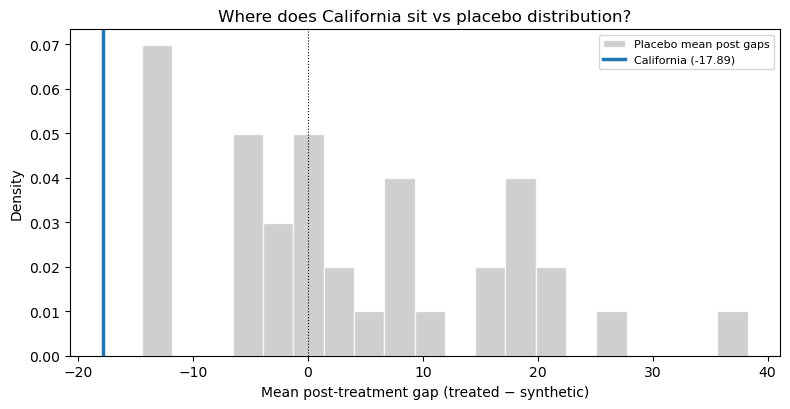

In [4]:
N_PLACEBO = 500  # upper bound on donors to use; effective n = min(N_PLACEBO, len(donor_states)) (~38 here)

gaps_placebo = []
for j in donor_states[:N_PLACEBO]:
    controls_j = [s for s in states if s != j]
    try:
        sj, dpj = fit_synth_california(
            j,
            controls_j,
            time_predictors_prior=time_pred,
            time_optimize_ssr=time_opt,
            paper_spec=False,
        )
        y1, y0, tix = synth_outcome_paths(dpj, sj, years_all)
        t0j = int(np.searchsorted(tix.to_numpy(), TREAT_YEAR))
        gaps_placebo.append(mean_post_gap(y1, y0, t0j))
    except Exception:
        gaps_placebo.append(np.nan)

gaps_placebo = np.asarray(gaps_placebo, dtype=float)
gaps_placebo = gaps_placebo[np.isfinite(gaps_placebo)]
gap_ca = mean_post_gap(Y_ca, Y_syn_ca, T0)

p_emp = np.mean(np.abs(gaps_placebo) >= abs(gap_ca))
print(f"California mean post gap (CA − synthetic): {gap_ca:.4f}")
print(f"Placebo gaps: n={len(gaps_placebo)}, mean={gaps_placebo.mean():.4f}, sd={gaps_placebo.std():.4f}")
print(f"Empirical two-sided p-value (|placebo| >= |CA|): {p_emp:.4f}")
print("(Placebos use paper_spec=False for speed; interpret as illustrative.)")

_n = len(gaps_placebo)
_bins = max(5, min(20, _n))
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(gaps_placebo, bins=_bins, density=True, alpha=0.75, color="0.75", edgecolor="white", label="Placebo mean post gaps")
ax.axvline(gap_ca, color="C0", lw=2.5, label=f"California ({gap_ca:.2f})")
ax.axvline(0.0, color="k", lw=0.8, linestyle=":")
ax.set_xlabel("Mean post-treatment gap (treated − synthetic)")
ax.set_ylabel("Density")
ax.set_title("Where does California sit vs placebo distribution?")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


---
# Part 4: Model evaluation — is the SC counterfactual credible?
---

Before trusting post-1989 gaps for California, check **pre-treatment fit**:

- **Pre-RMSPE (reported below):** root mean squared error between California and the **synthetic** path over **all pre-treatment years** in the panel (1970–1988 here). **Lower** suggests the weighted donors track California before treatment. (This is **not** the same thing as the **SSR loss window** 1984–1988 used **inside** `Synth` to estimate weights—those weights are chosen to fit especially well in that late-pre window.)
- **Comparison to naive benchmark:** RMSPE using the **unweighted donor mean** — if SC substantially **beats** this benchmark, the weights are doing meaningful work.

Large pre-RMSPE means the **synthetic path is a weak counterfactual** — interpret post gaps cautiously.


In [5]:
rmspe_sc = rmspe_pre_path(Y_ca, Y_syn_ca, T0)
rmspe_naive = rmspe_pre_path(Y_ca, donor_mean, T0)

print("Pre-treatment fit (lower is better), all pre years 1970–1988 (weights from Part 2 use SSR on 1984–1988):")
print(f"  pysyncon Synth (estimated w): RMSPE = {rmspe_sc:.4f}")
print(f"  Unweighted donor mean:       RMSPE = {rmspe_naive:.4f}")
print(
    "\nIf RMSPE for synthetic control is large relative to the benchmark, the post-1989 gap is harder "
    "to interpret as a policy effect alone."
)


Pre-treatment fit (lower is better), all pre years 1970–1988 (weights from Part 2 use SSR on 1984–1988):
  pysyncon Synth (estimated w): RMSPE = 2.3311
  Unweighted donor mean:       RMSPE = 16.0439

If RMSPE for synthetic control is large relative to the benchmark, the post-1989 gap is harder to interpret as a policy effect alone.


---
# Part 5: Augmented SC (`pysyncon`) and SDID (`synthdid`)
---

- **Augmented synthetic control (ridge ASC)** — Ben-Michael, Feller & Rothstein (2021). **`pysyncon.AugSynth`** fits the same **`Dataprep`** as Part 2, then adds a **ridge** adjustment to the SC weights (aligned with R `augsynth`, `progfunc="Ridge"`). Use **`att()`** for the average post-treatment gap vs the augmented synthetic path. Set **`lambda_`** to a number for a quick run, or **`None`** to choose the ridge penalty by **cross-validation** (slower).

- **Synthetic difference-in-differences** — Arkhangelsky et al. (2019). The **`synthdid`** package on PyPI estimates **$\tau$** with **data-driven unit weights $\omega$ and time weights $\lambda$** (not the hand-built weights from an earlier draft of this notebook). The next cell builds a long panel with **`D = 1`** for California in post-1989 years and **`0`** otherwise, then calls **`synthdid.sdid()`**.

**Requires:** `pysyncon` (Part 2). For SDID, install **`synthdid` with `--no-deps`** so pip does not pull pinned `numpy==1.23.5` (fails on Python 3.12+):  
`pip install "synthdid==0.10.1" --no-deps`  
after `numpy` / `pandas` / `matplotlib` are already installed (see `requirements.txt` comment). In Jupyter, use **`%pip install ...`** in a cell so the package installs into the **same Python as the notebook kernel**.

**Interpreting the estimates (units & sign):** The outcome is **`PacksPerCapita`** — **cigarette packs sold per person per year** in the state (same scale as in Abadie et al.’s smoking application). For **SC** and **ASC**, `att()` is the **average over post-treatment years** (1989–2000 here) of **(actual California − synthetic counterfactual)**. So **estimate = −17.9** means: in an average post year, California’s sales were about **17.9 packs per person lower** than the synthetic California path. **Negative** ⇒ California **below** the counterfactual (fewer packs sold). **SDID** reports **$\tau$** on the **same outcome**; **negative** again means California’s outcome is **below** the SDID comparison benchmark (see the SDID paper for the exact contrast).

**Comparing SC, ASC, and SDID:** A **side-by-side table of point estimates** (printed at the end of the next cell) helps students check **robustness** across methods. Caveats: (i) estimators are **related but not identical** (SC/ASC use `att()` on post gaps; SDID reports **$\tau$** with estimated **$\omega,\lambda$**); (ii) **SEs** from `att()` are **not** a substitute for design-based uncertainty (cf. Part 3 placebos); (iii) use the table for **magnitudes and robustness**, not a formal ranking of “inference.”


In [8]:
# Part 5: AugSynth (pysyncon) and SDID (PyPI `synthdid`). Requires Part 2 (`dp_ca`, `synth_ca`, `years_all`).
# SDID: %pip install "synthdid==0.10.1" --no-deps

from synthdid.sdid import sdid


post_years = [y for y in years_all if y >= TREAT_YEAR]

# Ridge ASC — same Dataprep as vanilla Synth; λ=None runs cross-validation (slower).
ASC_LAMBDA = 0.5  # or None for CV
aug_ca = AugSynth()
aug_ca.fit(dataprep=dp_ca, lambda_=ASC_LAMBDA)
print(f"AugSynth ridge λ = {aug_ca.lambda_}")

att_sc = synth_ca.att(time_period=post_years)
att_asc = aug_ca.att(time_period=post_years)
print("Vanilla SC — ATT over post years (mean gap, package SE):")
print(f"  {att_sc}")
print("Augmented SC (AugSynth) — ATT over post years:")
print(f"  {att_asc}")

sdid_tau = None
if sdid is not None:
    df_sdid = load_panel().copy()
    df_sdid["D"] = ((df_sdid["State"] == "California") & (df_sdid["Year"] >= TREAT_YEAR)).astype(int)
    sdid_res = sdid(df_sdid, "State", "Year", "D", "PacksPerCapita", covariates=None)
    sdid_tau = float(sdid_res["att"])
    print("SDID (synthdid package) — τ:")
    print(f"  {sdid_tau}")
else:
    print('SDID skipped — run: %pip install "synthdid==0.10.1" --no-deps')

rows = [
    ("SC (Synth)", att_sc["att"], att_sc["se"]),
    ("ASC (AugSynth)", att_asc["att"], att_asc["se"]),
]
if sdid_tau is not None:
    rows.append(("SDID (synthdid)", sdid_tau, np.nan))

comp = pd.DataFrame(rows, columns=["Method", "Estimate", "SE (package)"])
print("\nComparison — point estimates (see markdown: units = packs/person/year; negative = CA below counterfactual):")
for _, r in comp.iterrows():
    se = f"{r['SE (package)']:.4f}" if pd.notna(r["SE (package)"]) else "—"
    print(f"  {r['Method']:<18}  estimate = {r['Estimate']:>9.4f}   SE = {se}")
print(
    "\nExample: SC estimate ≈ −18 means ~18 fewer packs per person per year on average in 1989–2000 "
    "than synthetic California (mean of actual − synthetic over those post years)."
)


AugSynth ridge λ = 0.5
Vanilla SC — ATT over post years (mean gap, package SE):
  {'att': -17.88695838766207, 'se': 1.7377057795170439}
Augmented SC (AugSynth) — ATT over post years:
  {'att': -10.337264753151992, 'se': 1.4386880146042138}
SDID (synthdid package) — τ:
  -15.60383

Comparison — point estimates (see markdown: related estimands; SEs illustrative):
  SC (Synth)          estimate =  -17.8870   SE = 1.7377
  ASC (AugSynth)      estimate =  -10.3373   SE = 1.4387
  SDID (synthdid)     estimate =  -15.6038   SE = —
